In [1]:
import numpy as np
from dataclasses import dataclass
from functools import partial
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

import torch

from lingua.optim import build_optimizer, OptimArgs

/usr/workspace/wsb/kirchenb/tuolumne_conda_27_630_lingua/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# old

# lr_cfg = {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 1.0e-3,
#     "lr_min_ratio": 0.000001,
# }
# lr_cfg = {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-1,
# }
# lr_cfg = {
#     "scheduler": "wsd",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-4,
#     "decay_fraction": 1.0e-1, # fraction of the total steps for decay
# }
# lr_cfg = {
#     "scheduler": "wsd",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-4,
#     "decay_fraction": 3.33333e-1,
# }
# lr_cfg = {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 2.0e-3,
#     "lr_min_ratio": 0.000001,
# }


Simulating linear: 100%|██████████| 239000/239000 [00:04<00:00, 57210.60it/s]


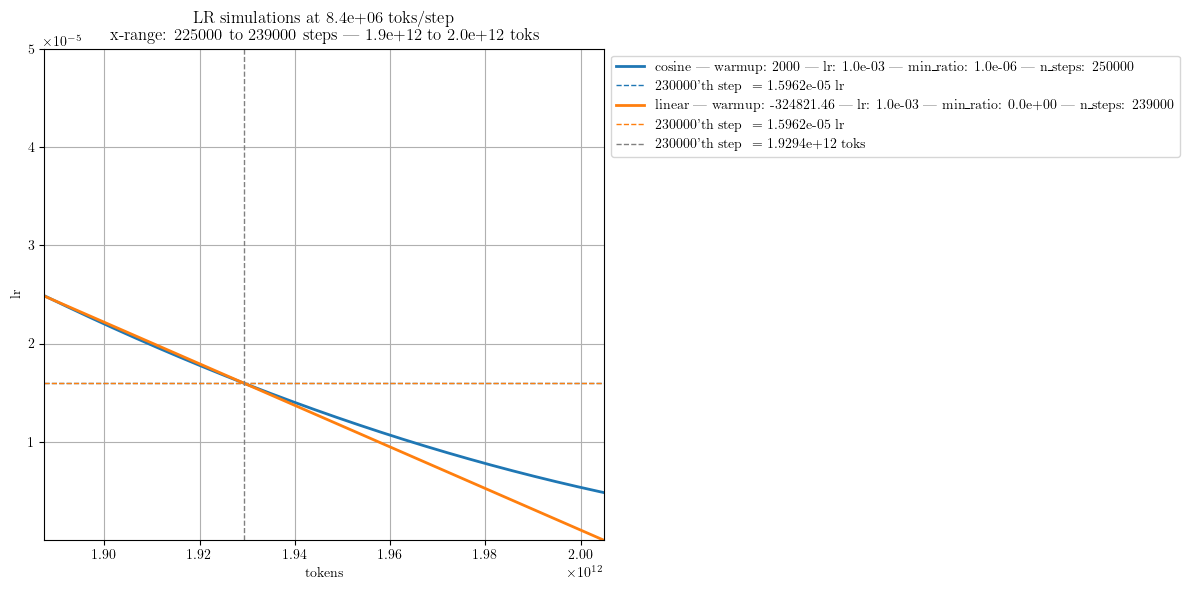

In [3]:
# base_n_steps = 500_000
# toks_per_step_world = 1 * (64*4*2) * 4096

# # x_lim_steps = (0, base_n_steps)
# # y_lim = None
# # save_name = f"comma_1T_lr_scheduler_simulation.png"

# x_lim_steps = (450_000, 478_000)
# y_lim = (1e-8, 5e-5)
# save_name = f"comma_1T_lr_scheduler_simulation_zoom.png"

# # add a v line at a specific step
# spec_step = 460_000

# lr_cfg_list = [
#     {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 1.0e-3,
#     "lr_min_ratio": 0.000001,
#     "n_steps": 500_000,
#     },
#     {
#     "scheduler": "linear",
#     # "warmup": -1118655,
#     "warmup": -658722.45,
#     "lr": 1e-3,
#     "lr_min_ratio": 0.0,
#     "n_steps": 478_000,
#     },
# ]


base_n_steps = 250_000
toks_per_step_world = 1 * (128*4*4) * 4096

# x_lim_steps = (0, base_n_steps)
# y_lim = None
# save_name = f"comma_2T_lr_scheduler_simulation.png"

x_lim_steps = (225_000, 239_000)
y_lim = (1e-8, 5e-5)
save_name = f"comma_2T_lr_scheduler_simulation_zoom.png"
# save_name = f"questionable_comma_2T_lr_scheduler_simulation_zoom.png"

# add a v line at a specific step
spec_step = 230_000

lr_cfg_list = [
    {
    "scheduler": "cosine",
    "warmup": 2000,
    # "lr": 2.0e-3,
    "lr": 1.0e-3,
    "lr_min_ratio": 0.000001,
    "n_steps": 250_000,
    },
    {
    "scheduler": "linear",
    # "warmup": -563821.46,
    "warmup": -324821.46,
    # "lr": 2e-3,
    "lr": 1e-3,
    "lr_min_ratio": 0.0,
    "n_steps": 239_000,
    },
]

plt.figure(figsize=(12, 6))

x_lim = (x_lim_steps[0] * toks_per_step_world, x_lim_steps[1] * toks_per_step_world)

title_string = f"LR simulations at {toks_per_step_world:.1e} toks/step\nx-range: {x_lim_steps[0]} to {x_lim_steps[1]} steps | {x_lim[0]:.1e} to {x_lim[1]:.1e} toks"
for lr_cfg in lr_cfg_list:
    n_steps = lr_cfg.pop("n_steps", base_n_steps)

    args = OptimArgs(**lr_cfg)

    # fake model with one parameter
    class FakeModule(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.linear = torch.nn.Linear(10, 10)

        def forward(self, x):
            return x
        def __repr__(self):
            return "fake model"
    model = FakeModule()

    optimizer, scheduler = build_optimizer(model, args, n_steps)

    # all_lrs = [lr_fn(i) for i in range(n_steps)]
    all_lrs = []
    for i in tqdm(range(n_steps), total=n_steps, desc=f"Simulating {args.scheduler}"):
        all_lrs.append(optimizer.param_groups[0]["lr"])
        optimizer.step()
        scheduler.step()

    x = np.arange(n_steps)
    x = x * toks_per_step_world
    y = np.array(all_lrs)
    plt.plot(x, y, label=f"{args.scheduler} | warmup: {args.warmup} | lr: {args.lr:.1e} | min_ratio: {args.lr_min_ratio:.1e} | n_steps: {n_steps}", linewidth=2)
    plt.xlabel("tokens")
    plt.ylabel("lr")

    # add an hline at the y value corresponding ~ to the spec_step, matching the color of the line
    spec_lr = all_lrs[spec_step] if spec_step < len(all_lrs) else all_lrs[-1]
    plt.axhline(y=spec_lr, color=plt.gca().lines[-1].get_color(), linestyle='--', linewidth=1, label=f"{spec_step}'th step ~= {spec_lr:.4e} lr")


spec_tok_ct = spec_step * toks_per_step_world
plt.axvline(x=spec_tok_ct, color='gray', linestyle='--', linewidth=1, label=f"{spec_step}'th step ~= {spec_tok_ct:.4e} toks")

plt.xlim(x_lim)

if y_lim is not None:
    plt.ylim(y_lim)

# plt.legend()
# move legend to the right outside the plot but dont squish the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.title(title_string)
plt.grid()
plt.tight_layout()
# plt.show()

plt.savefig(save_name)

## plan for how to stich a linear cooldown to an existing cosine in lingua

In [ ]:
# Colin's hq cd lr cfg block was 

lr: 1e-3
weight_decay: 0.2
warmup: -1118655
lr_min_ratio: 0.0
scheduler: "linear"
clip: 1.0

In [107]:
# 1. figure out the slope of the line for decay start to end point and steps
# 2. If im at this rate, figure out where a triangle peaking at the original peak values step peak _would_ be, could be negative, and then use this as the warmup end point (duration)

# plot to be sure that it intersects the line at the right point and that the slope is correct and that it hits zero at the desired end step

# peak_lr = 1e-3
# decay_lr0 = 1.5835e-5
# decay_lr1 = 0.0
# decay_start_step = 460_000
# decay_end_step = 478_000

peak_lr = 2e-3
decay_lr0 = 3.1925e-5
decay_lr1 = 0.0
decay_start_step = 230_000
decay_end_step = 239_000

def find_slope_and_warmup_end_point():
    """
    Calculate the slope of the line specifying the decay segment.
    Then calculate the warmup end point based on the peak learning rate, slope, and steps.
    The warmup end point is the x value where line with the same slope that passes through 
    the decay start point would achieve the peak lr.
    """
    slope = (decay_lr1 - decay_lr0) / (decay_end_step - decay_start_step)

    print(f"Slope of the decay line: {slope:.6e} lr/step")

    x_val = (peak_lr - decay_lr0) / slope + decay_start_step 
    # x_val = (peak_lr - decay_lr1) / slope + decay_end_step # equiv
    # x_val = (peak_lr / slope) + decay_end_step # equiv
    
    # this gives an answer that appears "wrong" but closer to the original
    # could the offset have been ommitted in the original calculation?
    # x_val = (peak_lr / slope)


    return x_val

warmup_duration = find_slope_and_warmup_end_point()
print(f"Calculated warmup end point: {warmup_duration:.2f} steps")

Slope of the decay line: -3.547222e-09 lr/step
Calculated warmup end point: -324821.46 steps


In [1]:
# b = 1.5835944986344045e-05
# m = -1.5835944986344045e-05/18000

# # 1e-3 = mx + b

# x = (1e-3 - b) / m
# x

-1118654.6180554496

In [ ]:
We want 10 equally spaced checkpoints across the cooldown duration
so figure out the eval args needed to make sure we save these.

(460/500)*250 = 230

decay from 230k for 9k steps to try and actually nail 2T
